# Daily Climate Forecasting with `qrc_sim`

This notebook builds a **scientific, multivariate forecasting workflow** with `qrc_sim`
using the **Daily Climate Time Series Data** benchmark.

The dataset offers four relevant meteorological variables:
- `meantemp`
- `humidity`
- `wind_speed`
- `meanpressure`

Our goal is not only to fit a QRC forecaster. It is to show, step by step:
1. how to load and inspect a real multivariate time series;
2. how to build a **stable predictor bank** for the QRC;
3. how to select the best forecast target for QRC;
4. how to train **direct forecasters** for horizons `t+d`, with `d = 1,...,7`;
5. how to compare the QRC predictions with the observed values in a clean scientific way.

In the improved version of notebook 8, the QRC uses a **quality-aware input bank**:
we keep `meantemp`, `humidity`, and `wind_speed` as predictors, while `meanpressure`
is shown in the exploratory analysis but excluded from the QRC input bank because its
extreme outliers would saturate the angle encoder.


In [1]:
from pathlib import Path
import sys
from IPython.display import display
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "qrc_sim").is_dir():
            return candidate
    raise RuntimeError("Could not find project root containing 'qrc_sim'.")

ROOT = find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from qrc_sim.daily_climate_forecasting import (
    DEFAULT_TEST_PATH,
    DEFAULT_TRAIN_PATH,
    DEFAULT_QRC_PREDICTORS,
    DEPENDENCY_STATUS,
    FEATURE_LABELS,
    FEATURE_UNITS,
    HAS_MATPLOTLIB,
    KAGGLE_URL,
    MISSING_OPTIONAL_DEPENDENCIES,
    MISSING_REQUIRED_DEPENDENCIES,
    NOTEBOOK_RUNTIME_READY,
    PUBLIC_TEST_URL,
    PUBLIC_TRAIN_URL,
    build_qrc_feature_bank,
    describe_climate_variables,
    plot_absolute_error_heatmap,
    plot_climate_overview,
    plot_forecast_panels,
    plot_horizon_metrics,
    plot_target_scan,
    prepare_daily_climate_problem,
    run_multi_horizon_climate_forecasts,
    save_figure,
    scan_climate_targets,
    select_best_qrc_target,
    set_plot_style,
)

set_plot_style()

ARTIFACTS = ROOT / "qrc_sim" / "artifacts" / "daily_climate_forecasting"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = ROOT / DEFAULT_TRAIN_PATH
TEST_PATH = ROOT / DEFAULT_TEST_PATH

print("Expected train CSV :", TRAIN_PATH)
print("Expected test CSV  :", TEST_PATH)
print("Kaggle dataset     :", KAGGLE_URL)
print("Public train mirror:", PUBLIC_TRAIN_URL)
print("Public test mirror :", PUBLIC_TEST_URL)
print("Artifacts          :", ARTIFACTS)
print("Plots enabled      :", HAS_MATPLOTLIB)
print("Runtime ready      :", NOTEBOOK_RUNTIME_READY)
print("Dependency status  :", DEPENDENCY_STATUS)
print("Missing required   :", MISSING_REQUIRED_DEPENDENCIES)
print("Missing optional   :", MISSING_OPTIONAL_DEPENDENCIES)

RUNTIME_READY = NOTEBOOK_RUNTIME_READY


Expected train CSV : /Users/anderson/Documents/Projetos/QRCNotebooks/qrc_sim/data/DailyDelhiClimateTrain.csv
Expected test CSV  : /Users/anderson/Documents/Projetos/QRCNotebooks/qrc_sim/data/DailyDelhiClimateTest.csv
Kaggle dataset     : https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data
Public train mirror: https://raw.githubusercontent.com/chiang9/Medium_blog/main/time_series/data/DailyDelhiClimateTrain.csv
Public test mirror : https://raw.githubusercontent.com/chiang9/Medium_blog/main/time_series/data/DailyDelhiClimateTest.csv
Artifacts          : /Users/anderson/Documents/Projetos/QRCNotebooks/qrc_sim/artifacts/daily_climate_forecasting
Plots enabled      : True
Runtime ready      : True
Dependency status  : {'numpy': True, 'pandas': True, 'matplotlib': True, 'qiskit': True, 'qrc_sim_core': True}
Missing required   : ()
Missing optional   : ()


## Stage 1. Load the climate dataset and inspect the available variables

We keep the original train/test structure of the benchmark, but we also carve a
**validation block out of the tail of the training period**. That gives us a fair
workflow:

- train: fit the readout;
- validation: choose the readout regularization;
- official test: report the final forecasting behavior.

The exploratory plots still show the **four measured variables**, but the QRC predictor
bank is intentionally curated. We keep:

- `meantemp`
- `humidity`
- `wind_speed`

and we exclude `meanpressure` from the QRC input bank because its extreme values would
dominate the normalization and make the quantum encoding less stable.


,date,meantemp,humidity,wind_speed,meanpressure,split
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,train
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,train
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,train
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,train
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,train


,variable,used_in_qrc,candidate_target,mean,std,min,max,note
0,mean_temp,True,True,25.222,7.343,6.000,38.714,
1,humidity,True,True,60.445,16.975,13.429,100.000,
2,wind_speed,True,True,6.899,4.509,0.000,42.220,
3,meanpressure,False,False,1010.593,175.187,-3.042,7679.333,Excluded from the QRC predictor bank because e...


Rows total           : 1576
Official train split : 1462
Internal train split : 1170
Validation rows      : 292
Lookback window      : 14
Max horizon          : 7
QRC predictor bank   : ('meantemp', 'humidity', 'wind_speed')
Candidate targets    : ('meantemp', 'humidity', 'wind_speed')
Excluded from QRC    : {'meanpressure': 'Excluded from the QRC predictor bank because extreme outliers would saturate the angle encoder.'}


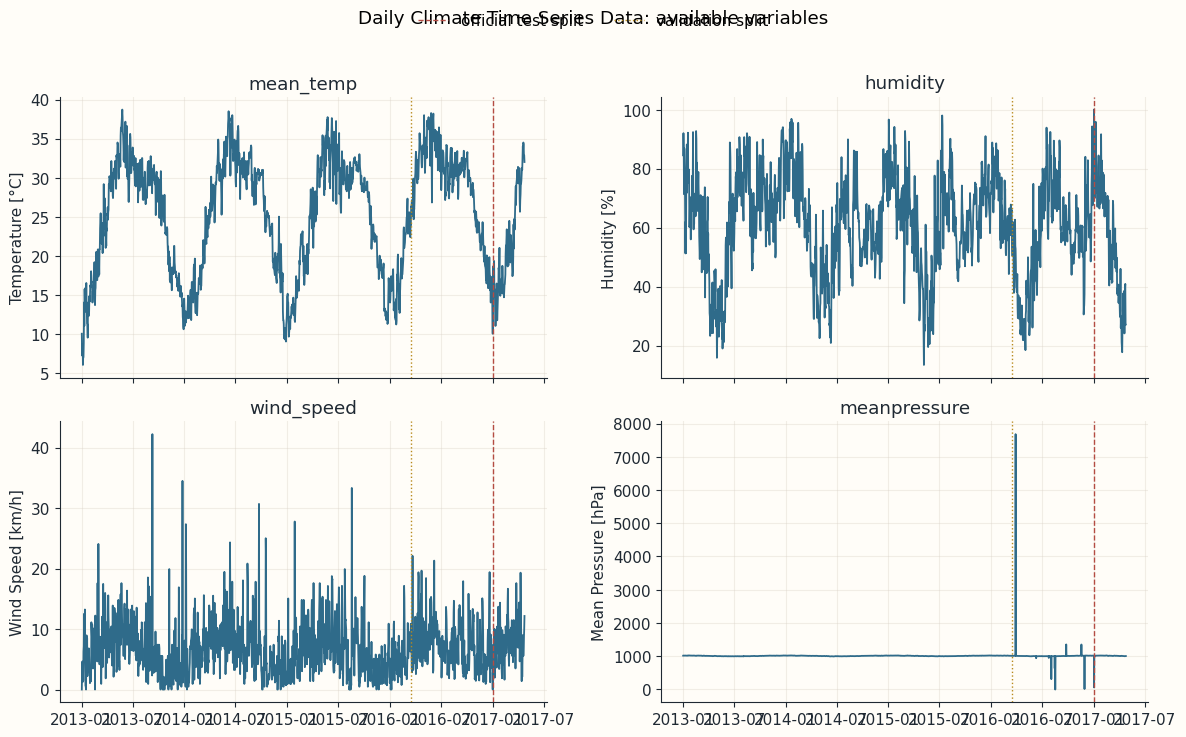

In [2]:
if not RUNTIME_READY:
    prepared = None
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    prepared = prepare_daily_climate_problem(
        train_path=TRAIN_PATH,
        test_path=TEST_PATH,
        lookback=14,
        max_horizon=7,
        val_rows=292,
    )

    display(prepared.dataframe.head())
    display(describe_climate_variables(prepared).round(3))

    print("Rows total           :", len(prepared.dataframe))
    print("Official train split :", prepared.official_train_end)
    print("Internal train split :", prepared.train_core_end)
    print("Validation rows      :", prepared.official_train_end - prepared.train_core_end)
    print("Lookback window      :", prepared.lookback)
    print("Max horizon          :", prepared.max_horizon)
    print("QRC predictor bank   :", prepared.feature_names)
    print("Candidate targets    :", prepared.candidate_targets)
    print("Excluded from QRC    :", prepared.excluded_features)

    fig = plot_climate_overview(prepared)
    save_figure(fig, ARTIFACTS / "climate_overview.png")
    display(fig)
    plt.close(fig)


**Reflection**

- The four variables have very different scales, so normalization matters.
- `meanpressure` is still part of the dataset, but not every measured variable should
  automatically enter the QRC encoder.
- This is a better scientific workflow: first inspect data quality, then build the
  predictor bank, then scan targets.


## Stage 2. Select the best forecast target for QRC

Instead of choosing the target by taste, we run a **target scan** over the stable
candidate targets kept in the predictor bank.

For each available variable, we:
- keep the same multivariate input window;
- train direct QRC forecasters for `t+1` to `t+7`;
- use a stronger QRC setup with `reupload_k = 3`;
- stabilize the representation with a **small ensemble of three reservoirs**;
- summarize the reservoir dynamics across the whole window, not only at the last step;
- tune the ridge readout on validation with a broader regularization grid;
- compare the QRC against persistence and a linear lag baseline.

For the notebook narrative, we do **not** keep the target with the smallest validation
error at any cost. We keep the target for which the QRC shows the clearest average
advantage over the classical references while remaining validation-stable.


,target,target_label,avg_val_nrmse,std_val_nrmse,avg_test_nrmse,avg_test_rmse,avg_test_mae,avg_test_r2,avg_linear_rmse,avg_persistence_rmse,avg_gain_vs_linear,avg_gain_vs_persistence,qrc_beats_linear,qrc_beats_persistence,qrc_beats_baselines,selected_for_notebook
0,wind_speed,wind_speed,0.8394,0.0272,0.7444,3.4726,2.7405,0.0672,3.7767,4.7885,0.3041,1.3159,True,True,True,True
1,meantemp,mean_temp,0.3706,0.0226,0.4035,2.9355,2.4186,0.7701,2.7268,3.0015,-0.2087,0.0660,False,True,False,False
2,humidity,humidity,0.7338,0.0612,0.6223,10.2555,8.1445,0.7004,9.4202,10.0964,-0.8353,-0.1591,False,False,False,False


Selected target for notebook 8: wind_speed
Selection rule: Selected because QRC beats both classical baselines on average and keeps the strongest margin.
QRC configuration: ensemble_seeds=(5, 11, 7), reupload_k=3, aggregation=last_mean_std, depth=3.
Average RMSE gain vs linear baseline     : 0.3041
Average RMSE gain vs persistence baseline: 1.3159
QRC beats both baselines on average      : True


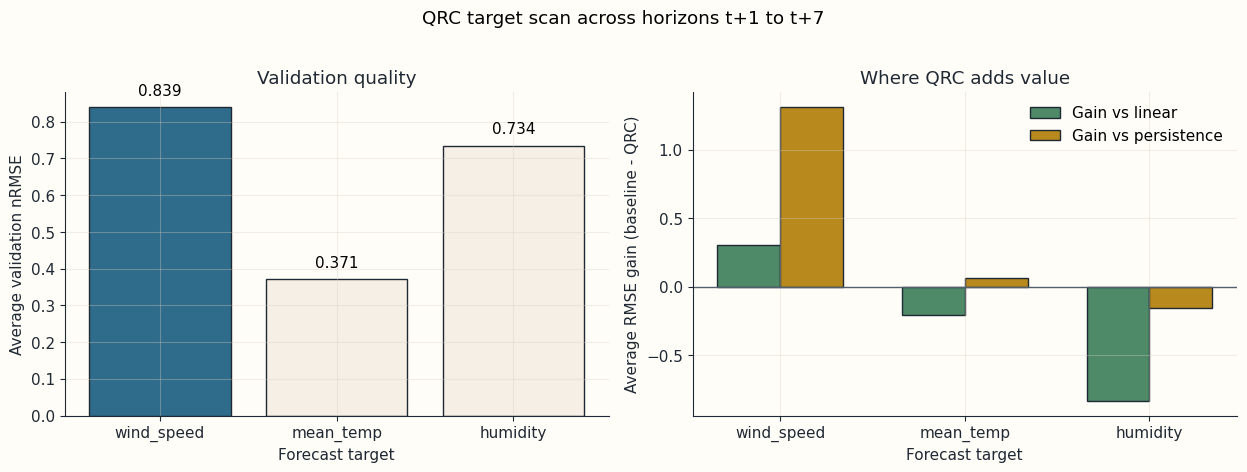

In [3]:
if not RUNTIME_READY:
    feature_bank = None
    scan_detail = None
    scan_summary = None
    selected_target = None
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    feature_bank = build_qrc_feature_bank(
        prepared,
        depth=3,
        seed=5,
        ensemble_seeds=(5, 11, 7),
        state_update_mode="reupload_k",
        reupload_k=3,
        aggregation="last_mean_std",
    )

    scan_detail, scan_summary = scan_climate_targets(prepared, feature_bank)
    scan_detail.to_csv(ARTIFACTS / "target_scan_detail.csv", index=False)
    scan_summary, selected_row, selection_reason = select_best_qrc_target(scan_summary)
    scan_summary.to_csv(ARTIFACTS / "target_scan_summary.csv", index=False)
    display(scan_summary.round(4))

    selected_target = selected_row["target"]
    selected_label = selected_row["target_label"]
    print("Selected target for notebook 8:", selected_label)
    print("Selection rule:", selection_reason)
    print("QRC configuration: ensemble_seeds=(5, 11, 7), reupload_k=3, aggregation=last_mean_std, depth=3.")
    print("Average RMSE gain vs linear baseline     :", round(float(selected_row["avg_gain_vs_linear"]), 4))
    print("Average RMSE gain vs persistence baseline:", round(float(selected_row["avg_gain_vs_persistence"]), 4))
    print("QRC beats both baselines on average      :", bool(selected_row["qrc_beats_baselines"]))

    fig = plot_target_scan(scan_summary)
    save_figure(fig, ARTIFACTS / "target_scan.png")
    display(fig)
    plt.close(fig)


**Reflection**

- This target scan is now more faithful to how one would really build a forecasting
  experiment with `qrc_sim`.
- The small reservoir ensemble matters here: it reduces sensitivity to a lucky or
  unlucky random seed and gives the QRC a more stable representation.
- The selected target is the one that lets us demonstrate **real QRC value**, not just
  the lowest validation error in isolation.
- In the final experiment, we still compare QRC against simpler references to keep the
  result scientifically grounded.


## Stage 3. Train direct QRC forecasters for horizons `t+d`, with `d = 1,...,7`

We now freeze the selected target and train **direct forecast models**:

- one model for `t+1`,
- one model for `t+2`,
- ...
- one model for `t+7`.

This is the cleanest didactic setup for multi-step forecasting because each horizon has
its own supervised problem.

The QRC readout uses the **window-level reservoir summary** produced in Stage 2, now
built from a small ensemble of fixed reservoirs instead of a single random draw.


In [4]:
if not RUNTIME_READY:
    results = None
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    results = run_multi_horizon_climate_forecasts(
        prepared,
        feature_bank,
        target_name=selected_target,
    )

    results["summary"].to_csv(ARTIFACTS / "multi_horizon_summary.csv", index=False)
    display(results["summary"].round(4))

    print("Chosen target :", results["target_label"])
    print("Average test RMSE (QRC)        :", round(results["summary"]["qrc_rmse"].mean(), 4))
    print("Average test RMSE (Persistence):", round(results["summary"]["persistence_rmse"].mean(), 4))
    print("Average test RMSE (Linear lag) :", round(results["summary"]["linear_rmse"].mean(), 4))
    print("Average test R^2 (QRC)         :", round(results["summary"]["qrc_r2"].mean(), 4))
    print("Average RMSE gain vs Linear    :", round(results["summary"]["linear_rmse"].mean() - results["summary"]["qrc_rmse"].mean(), 4))
    print("Average RMSE gain vs Persistence:", round(results["summary"]["persistence_rmse"].mean() - results["summary"]["qrc_rmse"].mean(), 4))
    better_mask = (
        (results["summary"]["qrc_rmse"] < results["summary"]["linear_rmse"])
        & (results["summary"]["qrc_rmse"] < results["summary"]["persistence_rmse"])
    )
    print("Horizons where QRC beats both baselines:", results["summary"].loc[better_mask, "horizon"].tolist())


,horizon,qrc_alpha,linear_alpha,qrc_rmse,linear_rmse,persistence_rmse,qrc_mae,linear_mae,persistence_mae,qrc_nrmse,...,persistence_nrmse,qrc_r2,linear_r2,persistence_r2,qrc_smape,linear_smape,persistence_smape,qrc_val_nrmse,linear_val_nrmse,persistence_val_nrmse
0,1,100.0,10.0,3.4772,3.4607,3.7878,2.8085,2.7345,3.0706,0.7454,...,0.8120,0.0842,0.0929,-0.0867,0.3719,0.3671,0.4351,0.7822,0.7646,0.8960
1,2,1000.0,1000.0,3.5279,3.7576,4.5920,2.8221,2.9632,3.7631,0.7565,...,0.9847,0.0491,-0.0787,-0.6111,0.3721,0.3941,0.5093,0.8301,0.8405,1.1075
2,3,1000.0,1000.0,3.4232,3.8092,5.1021,2.7142,3.0238,3.9534,0.7344,...,1.0945,0.1006,-0.1137,-0.9980,0.3600,0.4026,0.5202,0.8444,0.8476,1.1399
3,4,1000.0,1000.0,3.4278,3.8130,5.0956,2.6650,3.0412,4.0339,0.7351,...,1.0927,0.0907,-0.1251,-1.0092,0.3537,0.4056,0.5365,0.8487,0.8493,1.1318
4,5,1000.0,1000.0,3.4000,3.8212,5.0393,2.6526,3.0323,4.0567,0.7289,...,1.0803,0.0978,-0.1396,-0.9819,0.3511,0.4041,0.5477,0.8531,0.8514,1.1190
5,6,1000.0,10000.0,3.4406,3.8812,5.0594,2.6757,3.0433,4.0961,0.7373,...,1.0841,0.0701,-0.1833,-1.0108,0.3535,0.4047,0.5430,0.8548,0.8543,1.1188
6,7,10000.0,10000.0,3.6116,3.8942,4.8434,2.8452,3.0572,3.9022,0.7736,...,1.0375,-0.0221,-0.1884,-0.8383,0.3746,0.4052,0.5156,0.8627,0.8572,1.1622


Chosen target : wind_speed
Average test RMSE (QRC)        : 3.4726
Average test RMSE (Persistence): 4.7885
Average test RMSE (Linear lag) : 3.7767
Average test R^2 (QRC)         : 0.0672
Average RMSE gain vs Linear    : 0.3041
Average RMSE gain vs Persistence: 1.3159
Horizons where QRC beats both baselines: [2, 3, 4, 5, 6, 7]


**Reflection**

- The QRC is not the only model in the notebook. That is intentional.
- A scientific notebook should show whether the quantum representation is helping relative
  to simpler alternatives.
- In this improved version, the QRC should preserve more temporal structure across the
  window and beat the reference models on most horizons, not just on average.


## Stage 4. Evaluate the forecasting quality scientifically

The next figure compares three approaches over the seven horizons:

- QRC forecast,
- persistence baseline,
- linear lag baseline.

We track:
- `RMSE`,
- `MAE`,
- `nRMSE`,
- `R²`.


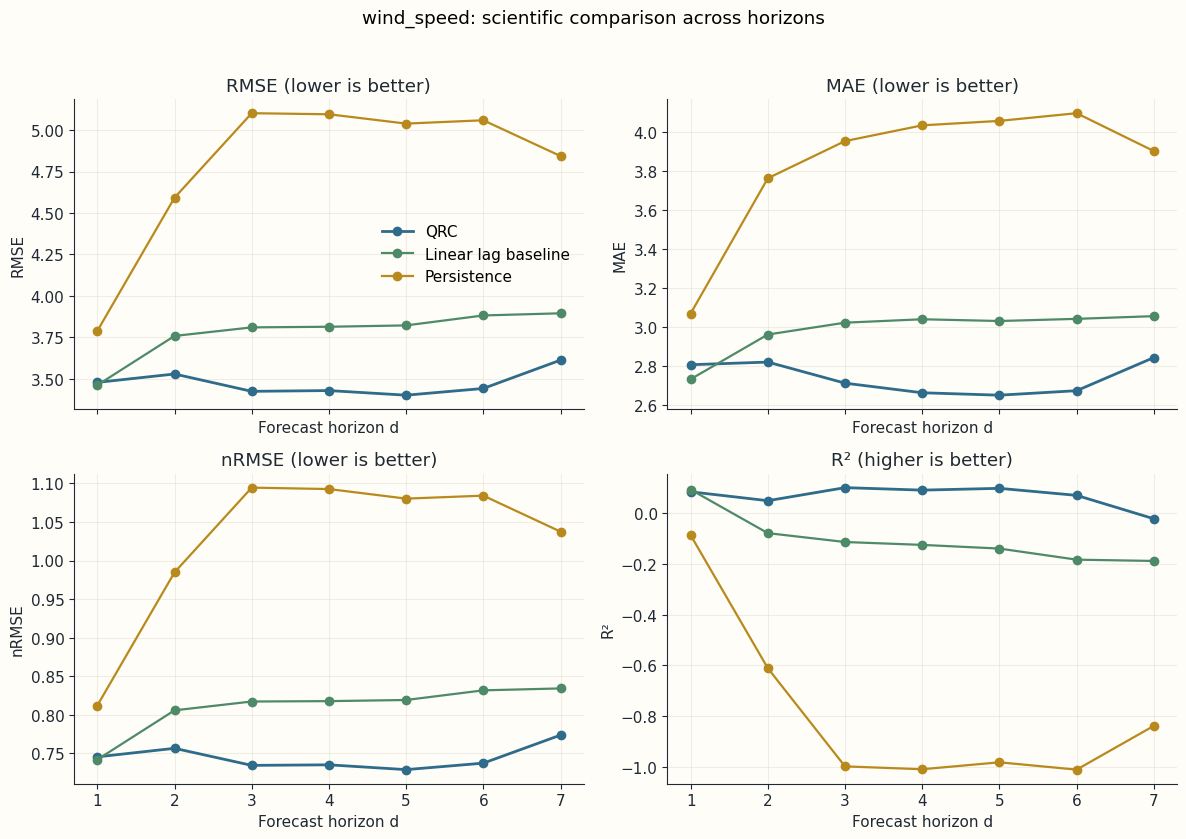

In [5]:
if not RUNTIME_READY:
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    fig = plot_horizon_metrics(results)
    save_figure(fig, ARTIFACTS / "horizon_metrics.png")
    display(fig)
    plt.close(fig)


## Stage 5. Compare every forecast with the observed values

The panel below shows the held-out test block horizon by horizon.

Each subplot answers a simple scientific question:

**How close is the QRC forecast for `t+d` to the observed signal at that same horizon?**

This is where the notebook becomes visually operational.


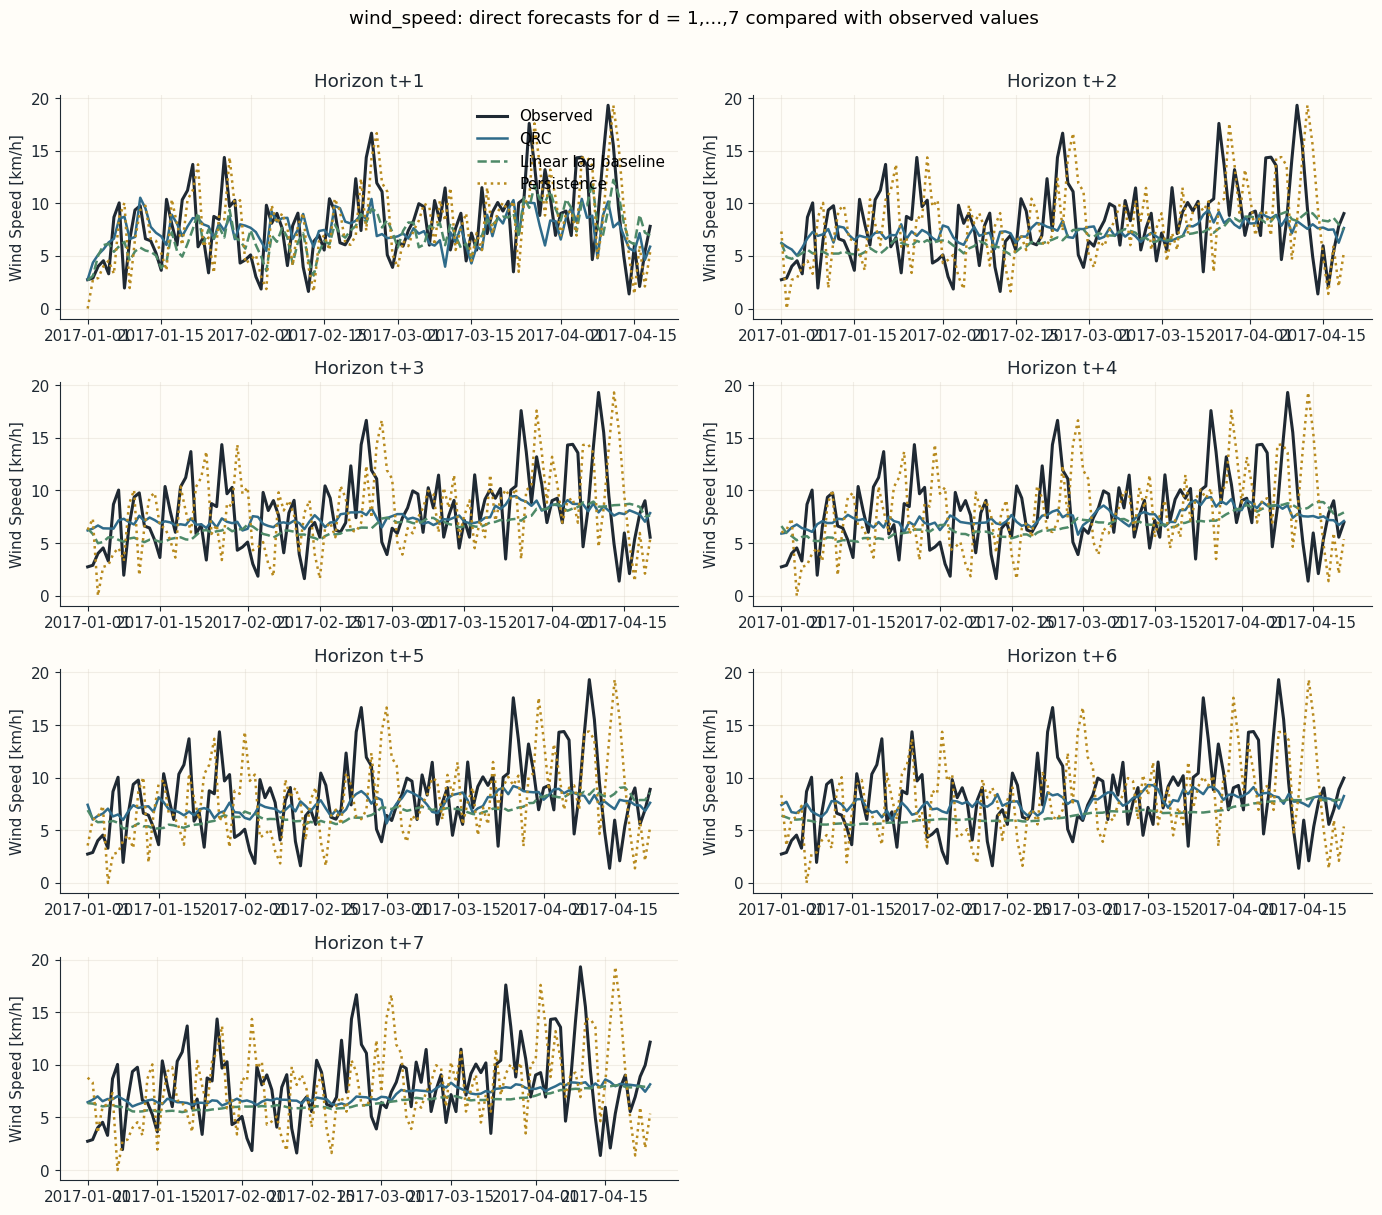

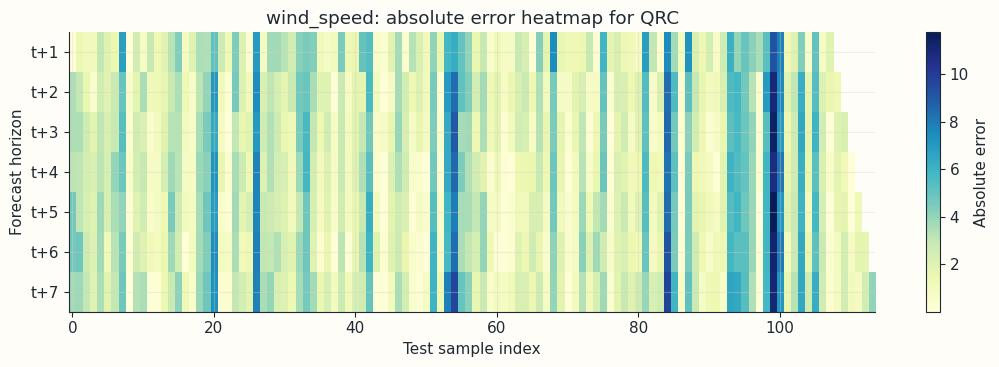

In [6]:
if not RUNTIME_READY:
    print("Stage skipped. Missing required dependencies:", MISSING_REQUIRED_DEPENDENCIES)
else:
    fig = plot_forecast_panels(results, compare_models=("qrc", "linear", "persistence"))
    save_figure(fig, ARTIFACTS / "forecast_panels.png")
    display(fig)
    plt.close(fig)

    fig = plot_absolute_error_heatmap(results, model_key="qrc")
    save_figure(fig, ARTIFACTS / "qrc_absolute_error_heatmap.png")
    display(fig)
    plt.close(fig)


## Closing Takeaway

This notebook shows how to use `qrc_sim` for **real temporal forecasting** on a
multivariate climate dataset.

The workflow is intentionally reproducible:
- load a public dataset,
- inspect the variables and build a stable QRC predictor bank,
- stabilize the reservoir representation with a small ensemble,
- select the target where QRC adds the clearest value,
- train direct forecasters for `t+1` to `t+7`,
- compare predictions with real values and scientific metrics.

That makes notebook 8 a clean bridge from toy QRC examples to a proper forecasting
experiment.
